# 03 · Explainability, fairness audit and failure analysis
Requires artifacts from notebook 02 (or `python -m src.train`).

In [15]:
import sys, glob, warnings
sys.path.insert(0, "..")            # make `src` importable from notebooks/
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.max_columns", 50, "display.width", 140)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

from src import features as ft, evaluate as ev, train as tr, fairness as fr

DATA = sorted(glob.glob("../data/*.xls*") + glob.glob("../data/*.csv"))[0]   # see data/README.md
print("Using", DATA)

Using ../data\default_of_credit_card_clients.xls


In [16]:
import joblib
from sklearn.base import clone
from src import explain as ex

art = joblib.load("../artifacts/model.joblib")
model, calibrator, thr = art["model"], art["calibrator"], art["threshold"]
C_FN, C_FP = art["c_fn"], art["c_fp"]

df = ft.add_group_labels(ft.clean(ft.load_raw(DATA)))
X, y = ft.get_xy(df)
te_idx, tr_idx = art["test_idx"], art["train_idx"]
X_te, y_te = X.iloc[te_idx].reset_index(drop=True), y.iloc[te_idx].reset_index(drop=True)
d_te = df.iloc[te_idx].reset_index(drop=True)

p_raw = model.predict_proba(X_te)[:, 1]
p_cal = calibrator.predict(p_raw)
flag = (p_cal >= thr).astype(int)
print(f"Threshold {thr:.3f} | flagged {flag.mean():.1%} of test customers | recall {flag[y_te==1].mean():.1%}")

Threshold 0.150 | flagged 48.5% of test customers | recall 77.5%


# Part A · Explainability (SHAP)
SHAP is computed on the raw log-odds output. Calibration is monotone, so ranking and direction of effects are unchanged.
*Global* plots show what drives risk in general. *Waterfalls* explain individual decisions, which is what a customer or regulator asks for.

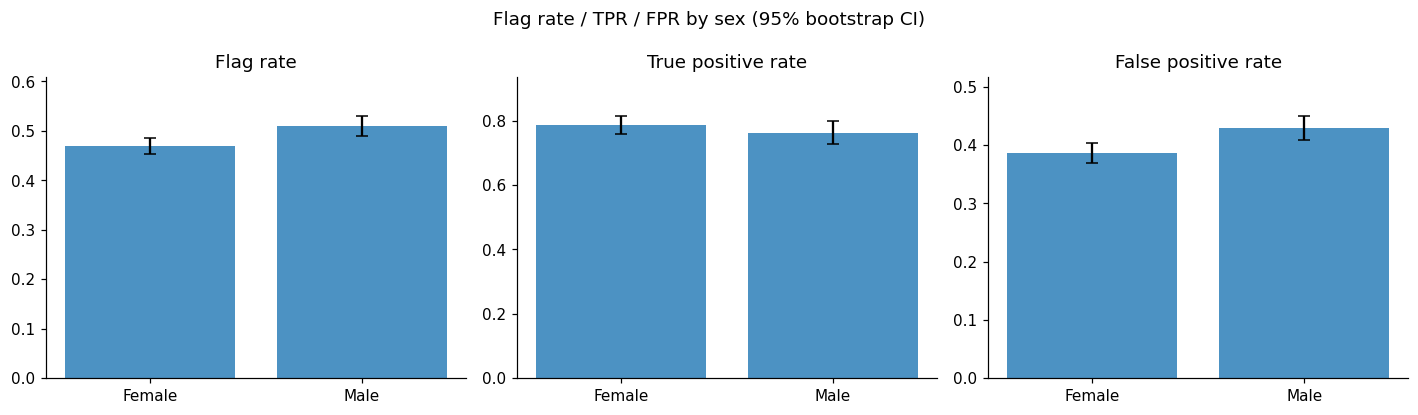

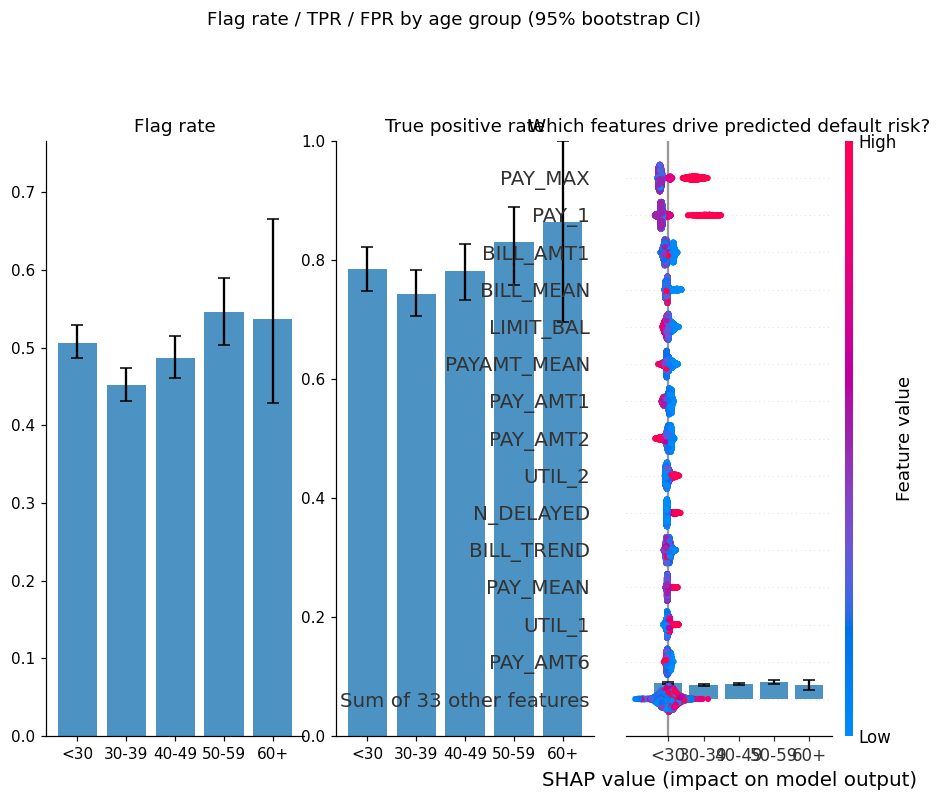

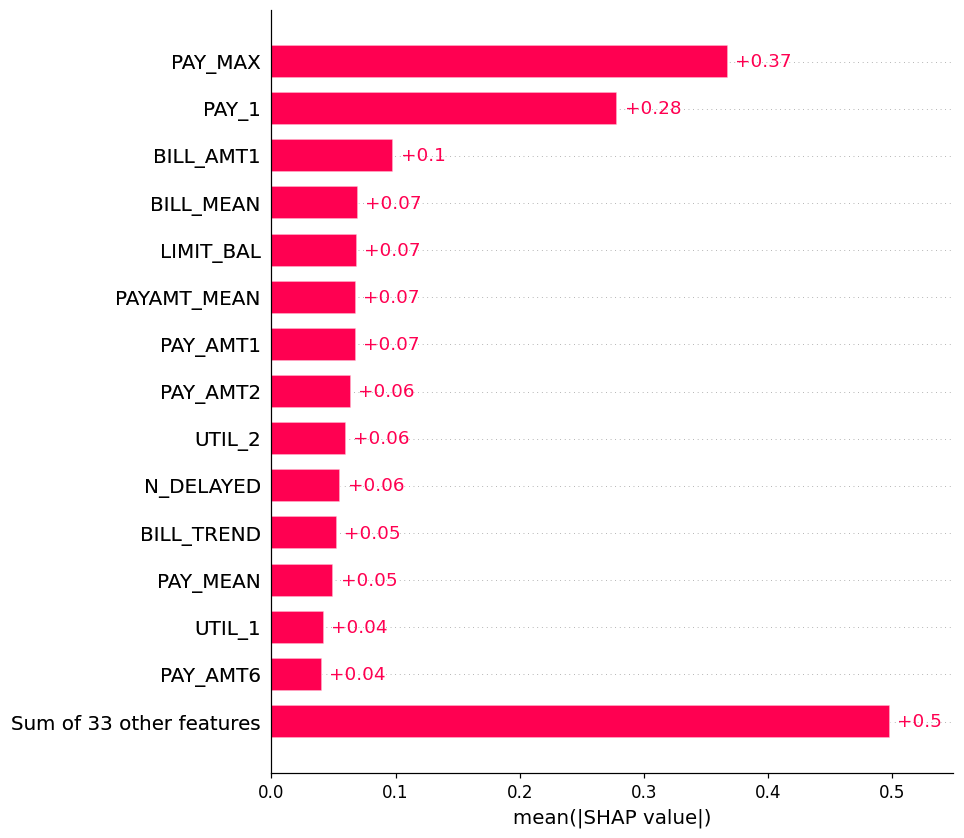

,mean_abs_shap
PAY_MAX,0.367519
PAY_1,0.278477
BILL_AMT1,0.098309
BILL_MEAN,0.069743
LIMIT_BAL,0.068802
PAYAMT_MEAN,0.068242
PAY_AMT1,0.067980
PAY_AMT2,0.063896
UTIL_2,0.059790
N_DELAYED,0.055513


In [17]:
sv = ex.compute_shap(model, X_te)
ex.plot_global(sv, max_display=15)
ex.top_features(sv, 10)

{'true_positive (caught defaulter)': 2402, 'false_negative (missed defaulter)': 1850, 'false_positive (false alarm)': 4380, 'true_negative (safe customer)': 3796}


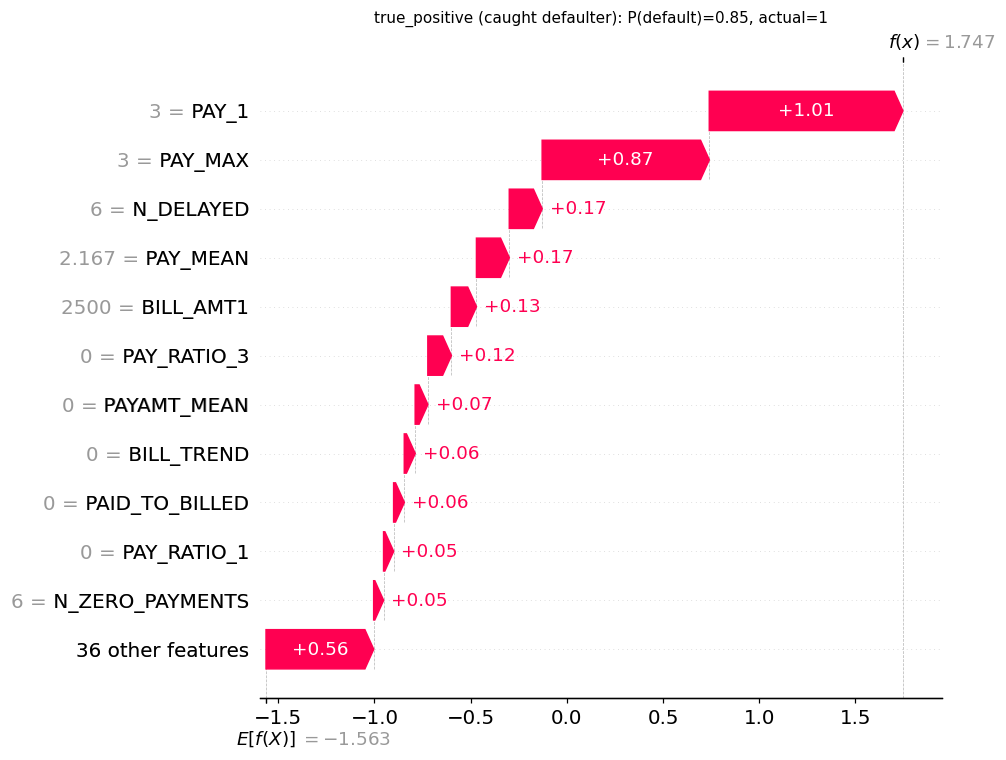

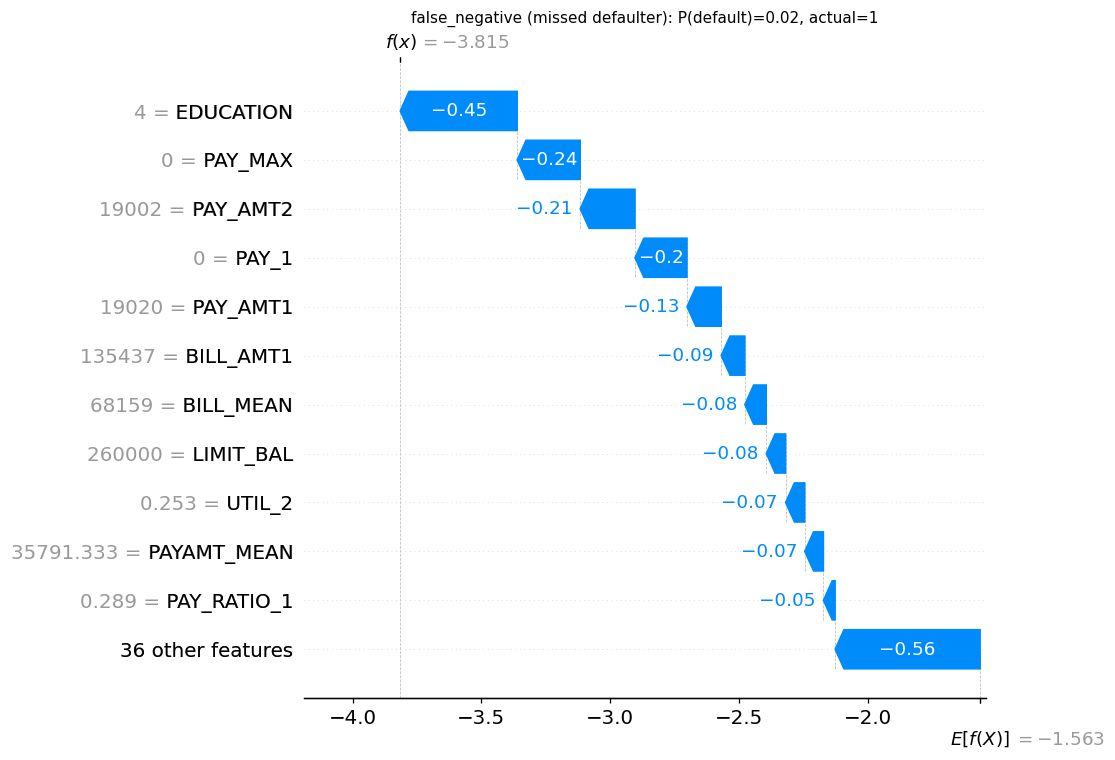

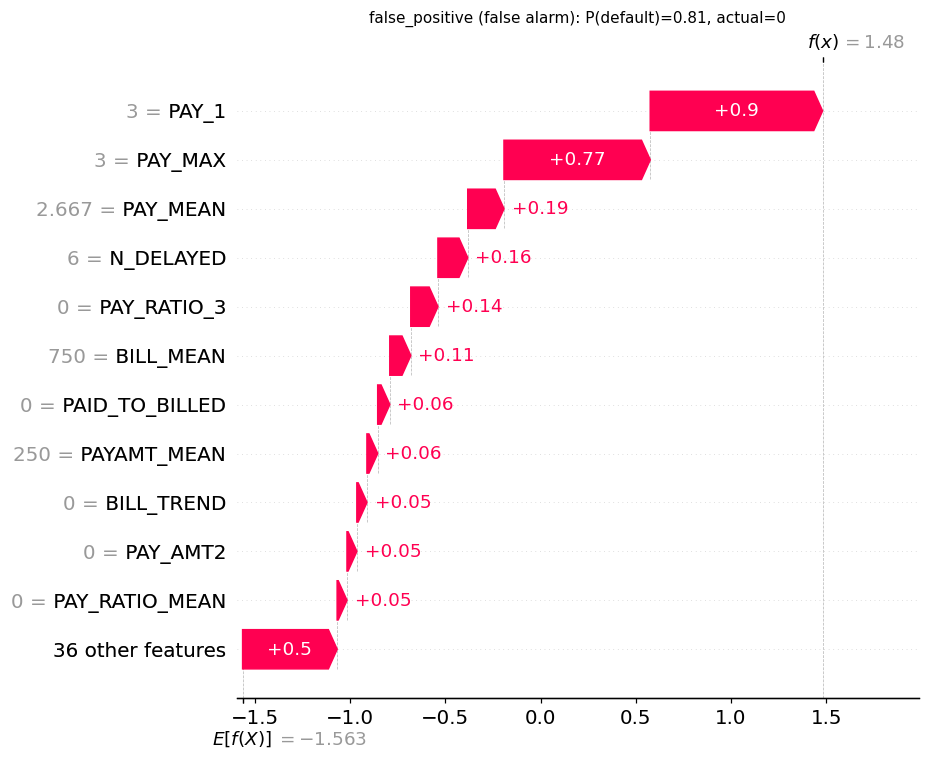

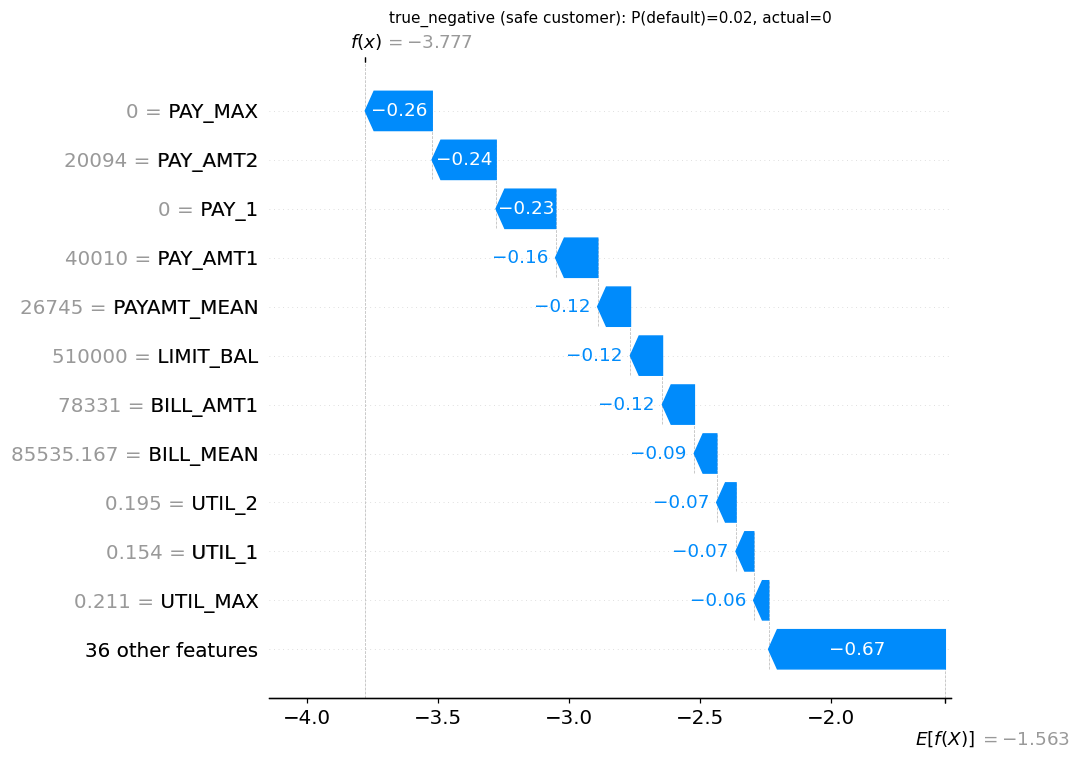

In [18]:
cases = ex.pick_cases(y_te.values, p_cal, thr)
print(cases)
ex.plot_waterfalls(sv, cases, p_cal, y_te)

# Part B · Fairness audit
**Setup.** SEX and MARRIAGE are *not* model inputs. AGE and EDUCATION are inputs, but all four are audited.
The "decision" is the flag (early intervention such as a limit change or payment plan), so a higher flag rate is the burden
group members bear. Metrics: flag rate (demographic parity), TPR (equal opportunity), FPR (with TPR: equalised odds),
PPV (predictive parity) and calibration by group.

In [19]:
audits = {"SEX_LABEL": "Sex", "AGE_GROUP": "Age group", "EDU_LABEL": "Education", "MARRIAGE_LABEL": "Marital status"}
tables = {}
for col, name in audits.items():
    gm = fr.group_metrics(y_te, flag, p_cal, d_te[col])
    tables[col] = gm
    print(f"\n=== {name} ==="); display(gm.round(3))
    display(fr.disparity_summary(gm).round(3).to_frame("value").T)


=== Sex ===


,n,base_rate,mean_score,calibration_gap,flag_rate,tpr,fpr,ppv,auc
group,,,,,,,,,
Female,3661,0.207,0.213,0.006,0.469,0.786,0.387,0.346,0.795
Male,2332,0.244,0.231,-0.013,0.511,0.761,0.430,0.364,0.761


,flag_rate_ratio (min/max),tpr_gap (max-min),fpr_gap (max-min),ppv_gap (max-min),base_rate_gap (max-min),max_abs_calibration_gap
value,0.919,0.025,0.043,0.017,0.037,0.013



=== Age group ===


,n,base_rate,mean_score,calibration_gap,flag_rate,tpr,fpr,ppv,auc
group,,,,,,,,,
30-39,2208,0.208,0.204,-0.005,0.452,0.743,0.375,0.343,0.775
40-49,1298,0.233,0.223,-0.011,0.487,0.782,0.397,0.375,0.789
50-59,493,0.249,0.241,-0.008,0.546,0.829,0.451,0.379,0.805
60+,67,0.328,0.237,-0.092,0.537,0.864,0.378,0.528,0.826
<30,1927,0.217,0.231,0.014,0.505,0.785,0.428,0.337,0.776


...

,n,base_rate,mean_score,calibration_gap,flag_rate,tpr,fpr,ppv,auc
group,,,,,,,,,
Grad school,2090,0.179,0.188,0.009,0.424,0.693,0.365,0.293,0.755
High school,1044,0.263,0.247,-0.016,0.550,0.829,0.450,0.397,0.781
Other,90,0.056,0.099,0.043,0.100,0.200,0.094,0.111,0.555
University,2769,0.242,0.238,-0.005,0.520,0.803,0.429,0.374,0.790


,flag_rate_ratio (min/max),tpr_gap (max-min),fpr_gap (max-min),ppv_gap (max-min),base_rate_gap (max-min),max_abs_calibration_gap
value,0.182,0.629,0.356,0.286,0.208,0.043



=== Marital status ===


,n,base_rate,mean_score,calibration_gap,flag_rate,tpr,fpr,ppv,auc
group,,,,,,,,,
Married,2756,0.241,0.222,-0.018,0.488,0.781,0.395,0.385,0.790
Other,65,0.231,0.260,0.029,0.569,0.733,0.520,0.297,0.687
Single,3172,0.204,0.217,0.013,0.481,0.770,0.407,0.327,0.776


,flag_rate_ratio (min/max),tpr_gap (max-min),fpr_gap (max-min),ppv_gap (max-min),base_rate_gap (max-min),max_abs_calibration_gap
value,0.846,0.048,0.125,0.088,0.036,0.029


## Are the gaps real or noise? Bootstrap CIs
Small groups (e.g. 60+) produce wide intervals. Do not report a gap without its uncertainty.

In [20]:
for col, name in [("SEX_LABEL", "Sex"), ("AGE_GROUP", "Age group")]:
    ci = fr.bootstrap_group_ci(y_te, flag, p_cal, d_te[col], n_boot=500)
    if col == "AGE_GROUP": ci = ci.reindex(["<30", "30-39", "40-49", "50-59", "60+"])
    fr.plot_group_ci(ci, f"Flag rate / TPR / FPR by {name.lower()} (95% bootstrap CI)", save=f"fairness_{col.lower()}.png")
    display(ci.round(3))

,flag_rate,flag_rate_lo,flag_rate_hi,tpr,tpr_lo,tpr_hi,fpr,fpr_lo,fpr_hi
group,,,,,,,,,
Female,0.469,0.453,0.486,0.786,0.757,0.814,0.387,0.369,0.404
Male,0.511,0.490,0.530,0.761,0.727,0.798,0.430,0.409,0.450


,flag_rate,flag_rate_lo,flag_rate_hi,tpr,tpr_lo,tpr_hi,fpr,fpr_lo,fpr_hi
group,,,,,,,,,
<30,0.505,0.486,0.529,0.785,0.747,0.822,0.428,0.406,0.456
30-39,0.452,0.431,0.474,0.743,0.706,0.782,0.375,0.352,0.397
40-49,0.487,0.461,0.515,0.782,0.732,0.827,0.397,0.368,0.427
50-59,0.546,0.503,0.590,0.829,0.758,0.889,0.451,0.405,0.506
60+,0.537,0.429,0.666,0.864,0.696,1.000,0.378,0.239,0.521


## Does "unawareness" work? Proxy check and a with/without-SEX comparison
Dropping SEX does not stop the model from using correlated features. We (1) test how well the model's inputs predict sex,
and (2) compare group gaps for a model *with* SEX against ours at the **same overall flag rate**.

In [21]:
print(f"AUC of predicting SEX from the model's input features: {fr.proxy_auc(X_te, d_te['SEX']):.3f}  (0.5 = no proxy information)")

X_s, _ = ft.get_xy(df, drop_protected=False)
m_sex = clone(model).fit(X_s.iloc[tr_idx], y.iloc[tr_idx])
s_sex = m_sex.predict_proba(X_s.iloc[te_idx].reset_index(drop=True))[:, 1]
s_main = p_raw
rows = []
for label, s in [("Without SEX (ours)", s_main), ("With SEX", s_sex)]:
    t = np.quantile(s, 1 - flag.mean())            # same overall flag rate
    f = (s >= t).astype(int)
    gm = fr.group_metrics(y_te, f, s, d_te["SEX_LABEL"])
    rows.append({"model": label, "roc_auc": ev.score_summary(y_te, s)["roc_auc"], "pr_auc": ev.score_summary(y_te, s)["pr_auc"],
                 **fr.disparity_summary(gm)[["flag_rate_ratio (min/max)", "tpr_gap (max-min)", "fpr_gap (max-min)"]].to_dict()})
pd.DataFrame(rows).set_index("model").round(4)

AUC of predicting SEX from the model's input features: 0.602  (0.5 = no proxy information)


,roc_auc,pr_auc,flag_rate_ratio (min/max),tpr_gap (max-min),fpr_gap (max-min)
model,,,,,
Without SEX (ours),0.7817,0.5691,0.9188,0.0250,0.0432
With SEX,0.7820,0.5697,0.9020,0.0114,0.0508


## Trade-offs: what would mitigation cost?
When groups have different base rates, flag-rate parity, equal TPR/FPR and calibration **cannot all hold at once**
(Chouldechova 2017; Kleinberg et al. 2016). Below: the price, in expected cost, of forcing equal TPR across sexes with
group-specific thresholds. This is analysis, **not** a recommendation.

In [22]:
exp = fr.group_threshold_experiment(y_te, p_cal, d_te["SEX_LABEL"], thr, C_FN, C_FP)
display(exp.round(4)); print("Group thresholds:", {k: round(v, 3) for k, v in exp.attrs["thresholds"].items()})

,policy,cost_per_customer,flag_rate,tpr_gap,fpr_gap,flag_rate_ratio
0,Single global threshold,0.5625,0.4854,0.0250,0.0432,0.9188
1,Group-specific thresholds (equal TPR),0.5592,0.4821,0.0004,0.0702,0.8702


Group thresholds: {'Female': 0.154, 'Male': 0.146}


**What I would do**
* Exclude SEX and MARRIAGE from the model; keep monitoring all four attributes after deployment.
* Report gaps with confidence intervals and tie them to base-rate differences, which are real and may reflect different circumstances.
* Review whether AGE and EDUCATION should be inputs. They may be legally restricted or proxies for something else; the with/without comparison shows what they cost.
* Make the flag a *supportive* intervention (payment plan, outreach) rather than an adverse action where possible: this changes what fairness requires.
* Keep a human in the loop for limit reductions and provide customer-facing reasons (the SHAP waterfalls are the starting point).

**What I would not do**
* Use group-specific thresholds on a protected attribute: that is disparate treatment and generally unlawful for sex in EU credit and insurance pricing.
* Claim the model is "fair" because SEX is removed: see the proxy test.
* Optimise one fairness metric blindly: they conflict, and the choice is a policy decision for risk, legal and compliance.

*(This is analysis, not legal advice. Regulatory details vary by jurisdiction and should be checked with counsel.)*

# Part C · Failure analysis
Where is the model wrong, and why? We look at the most confident errors, error rates by segment, and what distinguishes missed defaulters from caught ones.

In [23]:
errs = ev.confident_errors(X_te.assign(p_cal=p_cal), y_te.values, p_cal, thr, n=10)
cols = ["p_cal", "y", "LIMIT_BAL", "AGE", "PAY_1", "PAY_2", "PAY_MAX", "UTIL_MEAN", "PAY_RATIO_MEAN", "N_DELAYED"]
print("Most confident FALSE NEGATIVES (defaulted, scored very low):"); display(errs["false_negatives"][cols].round(3))
print("Most confident FALSE POSITIVES (did not default, scored very high):"); display(errs["false_positives"][cols].round(3))

Most confident FALSE NEGATIVES (defaulted, scored very low):


,p_cal,y,LIMIT_BAL,AGE,PAY_1,PAY_2,PAY_MAX,UTIL_MEAN,PAY_RATIO_MEAN,N_DELAYED
1850,0.022,1,260000,48,0,0,0,0.262,0.355,0
5077,0.026,1,500000,36,-2,-2,-2,0.074,1.005,0
4516,0.032,1,300000,31,0,0,0,0.087,0.608,0
607,0.037,1,300000,42,-1,0,0,0.093,0.436,0
2142,0.037,1,420000,31,0,0,0,0.656,0.075,0
2318,0.039,1,80000,37,-1,0,0,0.231,0.930,0
4332,0.039,1,150000,37,-2,-2,-2,0.060,1.005,0
1143,0.039,1,470000,35,0,0,0,0.380,0.043,0
4796,0.040,1,350000,32,-1,-1,-1,0.064,1.001,0
1233,0.042,1,220000,29,0,0,0,0.135,0.125,0


Most confident FALSE POSITIVES (did not default, scored very high):


,p_cal,y,LIMIT_BAL,AGE,PAY_1,PAY_2,PAY_MAX,UTIL_MEAN,PAY_RATIO_MEAN,N_DELAYED
4380,0.815,0,100000,38,3,2,3,0.008,0.000,6
2012,0.804,0,130000,50,2,2,2,0.595,0.035,6
3263,0.801,0,400000,39,2,2,2,0.131,0.040,6
814,0.797,0,100000,29,2,2,2,0.768,0.038,6
3528,0.797,0,60000,35,2,2,2,0.364,0.058,6
4897,0.790,0,140000,35,2,2,2,0.422,0.038,6
1108,0.785,0,60000,40,3,3,5,0.171,0.037,6
383,0.785,0,60000,35,2,2,2,0.098,0.172,6
3269,0.784,0,160000,30,2,2,2,0.493,0.040,6
5405,0.775,0,100000,48,2,2,2,0.177,0.060,5


In [24]:
seg_specs = [("PAY_1", None), ("LIMIT_BAL", [0, 30_000, 60_000, 120_000, 250_000, 1e7]), ("N_DELAYED", None), ("UTIL_MEAN", [-10, 0.1, 0.4, 0.8, 1.0, 10])]
for col, bins in seg_specs:
    print(f"\nError rates by {col}"); display(ev.error_by_segment(X_te, y_te, p_cal, thr, col, bins).round(3))


Error rates by PAY_1


,n,default_rate,flag_rate,miss_rate,false_alarm_rate
seg,,,,,
-2,583,0.134,0.338,0.500,0.313
-1,1154,0.160,0.424,0.362,0.383
0,2917,0.136,0.323,0.465,0.290
1,718,0.334,0.919,0.033,0.895
2,523,0.683,1.000,0.000,1.000
3,72,0.708,1.000,0.000,1.000
4,14,0.643,1.000,0.000,1.000
5,6,0.667,1.000,0.000,1.000
6,1,1.000,1.000,0.000,0.000



Error rates by LIMIT_BAL


,n,default_rate,flag_rate,miss_rate,false_alarm_rate
seg,,,,,
"(0.0, 30000.0]",809,0.347,0.888,0.057,0.858
"(30000.0, 60000.0]",885,0.271,0.608,0.179,0.529
"(60000.0, 120000.0]",1041,0.264,0.494,0.196,0.383
"(120000.0, 250000.0]",1897,0.172,0.410,0.315,0.353
"(250000.0, 10000000.0]",1361,0.149,0.265,0.404,0.207



Error rates by N_DELAYED


,n,default_rate,flag_rate,miss_rate,false_alarm_rate
seg,,,,,
0,3984,0.121,0.260,0.582,0.239
1,885,0.294,0.852,0.058,0.814
2,373,0.359,0.984,0.015,0.983
3,230,0.474,1.000,0.000,1.000
4,176,0.540,1.000,0.000,1.000
5,65,0.662,1.000,0.000,1.000
6,280,0.721,1.000,0.000,1.000



Error rates by UTIL_MEAN


,n,default_rate,flag_rate,miss_rate,false_alarm_rate
seg,,,,,
"(-10.0, 0.1]",2225,0.183,0.495,0.272,0.443
"(0.1, 0.4]",1248,0.171,0.308,0.258,0.218
"(0.4, 0.8]",1495,0.249,0.456,0.249,0.358
"(0.8, 1.0]",900,0.309,0.717,0.108,0.638
"(1.0, 10.0]",125,0.432,0.768,0.167,0.718


In [25]:
fn = (y_te.values == 1) & (p_cal < thr); tp = (y_te.values == 1) & (p_cal >= thr)
print(f"Missed defaulters: {fn.sum()}  |  caught defaulters: {tp.sum()}")
print("Standardised mean differences, missed vs caught defaulters (large |smd| = blind spot):")
ev.compare_groups(X_te, fn, tp, top=10).round(3)

Missed defaulters: 298  |  caught defaulters: 1028
Standardised mean differences, missed vs caught defaulters (large |smd| = blind spot):


,mean_a,mean_b,smd
N_DELAYED,0.064,2.571,-1.623
PAY_MAX,-0.225,1.700,-1.622
PAY_1,-0.460,0.977,-1.282
PAY_MEAN,-0.497,0.607,-1.053
PAY_2,-0.517,0.728,-1.026
N_ZERO_PAYMENTS,0.631,2.072,-0.905
PAY_3,-0.470,0.636,-0.875
PAY_4,-0.513,0.517,-0.796
PAY_5,-0.510,0.420,-0.722
N_REVOLVING,3.732,2.139,0.680
